# Week 4b.2: The Customer Support Agent

We'll now build the Husky Tech support agent in LangGraph.

The model in the previous notebook could *ask* for a tool and nothing ran it. 
We'll fix that in two steps: first a node that executes tool calls, then one edge that turns the result into an agent.

Here is where we are headed. Solid arrows are fixed edges; **dashed red arrows are conditional**, decided while the graph runs:

<img src="figures/graph_support_agent.png" width="360" alt="the customer support agent graph">

In [26]:
from dotenv import load_dotenv
import os

load_dotenv()
assert os.getenv("GOOGLE_API_KEY"), "No GOOGLE_API_KEY found."
print("API key loaded")

API key loaded


## 0. Model Setup

Execute one of the following to define the model.

If using Ollama, you will need to start it first (simply open the chat UI and send a message):
- https://docs.langchain.com/oss/python/integrations/chat/ollama

Verify that Ollama is serving a model:
- http://localhost:11434/

In [27]:
from langchain_ollama import ChatOllama

model = ChatOllama(model="qwen3.5:4b", reasoning=False)

In [28]:
# from langchain.chat_models import init_chat_model

# model = init_chat_model(model="gpt-4.1-mini")

In [29]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

## 1. The tools and the prompt

Both come from `support_tools.py`: the four tools you wrote in W03b, and the system
prompt that sets the agent's rules. Open that file and read it — the docstrings are
how the model chooses between the tools, and the prompt is where the guardrails live.

In [30]:
from support_tools import TOOLS, SYSTEM_PROMPT
# tools is a list of tools from the system prompt, each with a name and description. The system prompt is a string that describes the overall context and purpose of the tools.

for t in TOOLS:
    print(f"{t.name:26s} {t.description[:58]}")

print("\nSystem prompt:")
print(SYSTEM_PROMPT)

look_up_order              Look up an order by its id (e.g. HT-1001) and return its c
check_return_eligibility   Check whether an order can still be returned under the 30-
search_faq                 Answer general questions about shipping, returns, warranty
escalate_to_human          Escalate the conversation to a human support agent. Use wh

System prompt:
You are the customer support assistant for Husky Tech, an online electronics store.

Rules:
- Only answer questions about Husky Tech orders, products, and policies. Politely decline anything else.
- Never invent order details. Always use the tools to look up real data.
- If the customer is upset, asks for a person, or the tools cannot resolve the issue, use escalate_to_human.
- Be concise and polite.


In [31]:
from langchain.messages import SystemMessage, HumanMessage

sys_msg = SystemMessage(content=SYSTEM_PROMPT)
model_with_tools = model.bind_tools(TOOLS)

## 2. The assistant node

The assistant node will invoke the llm with tools with system prompt and message.

Note that the prompt is **not** stored in the state — it is added at call time, so the conversation cannot edit it away.

In [32]:
from langgraph.graph import StateGraph, MessagesState, START, END

def assistant(state: MessagesState) -> dict:
    context = [sys_msg] + state["messages"]
    response = model_with_tools.invoke(context)
    return {"messages": [response]}

## 3. The tool node

In Week 2b we ran tool calls by hand: read `tool_calls` off the last message, find the
matching function, invoke it, wrap the result in a `ToolMessage`. 

`ToolNode` is that same logic, prebuilt: hand it the list of tools and it handles any call to any of them.

- https://reference.langchain.com/python/langgraph/agents/#langgraph.prebuilt.tool_node.ToolNode

Define a tool node with: ToolNode([list_of_tools])

In [33]:
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(TOOLS)

## 4. Routing to the tools: `tools_condition`

After the assistant speaks there is exactly one question: did it ask for a tool?

- If yes, run the tools.
- If no, it answered in words, and we are done.

`tools_condition` is that question, prebuilt:
- it reads the last message and returns `"tools"` or `END`.

Let's build a router graph with these:

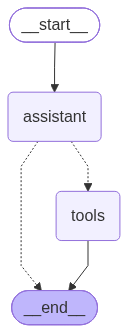

In [34]:
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display

builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant)
builder.add_node("tools", tool_node)


# TODO: Build the edges so assistant serves as a router between tool_node and END
builder.add_edge(START, "assistant")
builder.add_edge("assistant", END)
builder.add_edge("assistant", "tools")
builder.add_edge("tools", END)

builder.add_conditional_edges("assistant", tools_condition) # uses pre-built tools_condition to determine if the assistant should route to tools or END
router = builder.compile()

display(Image(router.get_graph().draw_mermaid_png()))

In [35]:
result = router.invoke({"messages": [
    HumanMessage(content="Hello")]})

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Hello! Welcome to Husky Tech customer support. How can I help you today with your orders, products, or store policies?', 'extras': {'signature': 'EmAKXgFpFH0Tj4DKExlaI1t6RtYLqZ1uluYEIWa8XRu3URLNsvN0yBBdD6y3nlugCLQUJ5RCxsXTK+y9sU/vMsPphGM8KhEgU1Gota2Vs7eiHm3wonbv8T1jlfAQD8/DozU='}}]


In [36]:
result = router.invoke({"messages": [
    HumanMessage(content="Can I return HT-1001?")]})

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Can I return HT-1001?
================================== Ai Message ==================================

[]
Tool Calls:
  check_return_eligibility (call_306020)
 Call ID: call_306020
  Args:
    order_id: HT-1001
================================= Tool Message =================================
Name: check_return_eligibility

Eligible: delivered 27 days ago; returns are accepted within 30 days of delivery.


The tool ran and the result is correct. 

But look at what the customer would actually receive: 
two raw tool outputs and no reply addressed to them. 

Nobody put the pieces together, because after the tools ran the graph stopped.

The model never saw the results. It asked a question and never got an answer.

## 5. The Agent Loop

We can turn the graph into a loop by adding an edge to send the tool results **back to the assistant**.

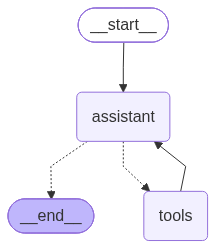

In [37]:
from langgraph.prebuilt import tools_condition

builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant)
builder.add_node("tools", tool_node)

builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")
builder.add_edge("assistant", END)

support_agent = builder.compile()
display(Image(support_agent.get_graph().draw_mermaid_png()))

In [38]:
result = support_agent.invoke({"messages": [
    HumanMessage(content="Hello")]})

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Hello! Welcome to Husky Tech customer support. How can I help you today with your orders, products, or store policies?', 'extras': {'signature': 'EmAKXgFpFH0TS36Xa1NwH8mDG6hcaCx/PPQ/88EW3YxP+Pykf4LkhnVaXr+FxaWCAtaPQmR0hQ+vZOnij9RSHxnv4KdTwa2zh17zYZc3d8T7xs4x3eOZdZAedVh1KjKjLmU='}}]


In [39]:
result = support_agent.invoke({"messages": [
    HumanMessage(content="Can I return HT-1001?")]})

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Can I return HT-1001?
================================== Ai Message ==================================

[]
Tool Calls:
  check_return_eligibility (call_19905)
 Call ID: call_19905
  Args:
    order_id: HT-1001
================================= Tool Message =================================
Name: check_return_eligibility

Eligible: delivered 27 days ago; returns are accepted within 30 days of delivery.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Yes, order HT-1001 is eligible for return. It was delivered 27 days ago, and items can be returned within 30 days of delivery.', 'extras': {'signature': 'EmAKXgFpFH0Th6dIgx1ruTKzx8Kt86ZHLWFMI6VXlKyDZsgzdVxk/j9PHsR6UmlARihb1uB36sBTn0EWGT0AOfaNb/0bI3aaw1dspAIKlzPjMu5jJI1L8oHlNAuS3hIawoM='}}]


The model read both tool results and answered the customer.

That edge is the whole difference between a workflow and an agent. 

The graph now has a **cycle**, so the model can go round as many times as the question needs.

E.g., look something up, read it, decide another tool is required, and only then answer. 

Nothing in our code says how many turns that takes; `tools_condition` ends the loop whenever
the model stops asking for tools.

## 6. Test drives

In [40]:
from langchain.messages import HumanMessage

questions = [HumanMessage(content="Where is my order HT-1002?"), 
             HumanMessage(content="Can I still return the headphones from order HT-1001?"),
             HumanMessage(content="What are your support hours?"),
             HumanMessage(content="This is the third time I am asking about my missing package and nobody helps. I want to talk to a person.")]

In [41]:
result = support_agent.invoke({"messages": [questions[0]]})

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Where is my order HT-1002?
================================== Ai Message ==================================

[]
Tool Calls:
  look_up_order (call_132952)
 Call ID: call_132952
  Args:
    order_id: HT-1002
================================= Tool Message =================================
Name: look_up_order

{'item': 'Mechanical keyboard', 'status': 'shipped', 'ordered_on': '2026-09-15', 'eta': '2026-09-23', 'price': 129.0}
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Order HT-1002 (Mechanical keyboard) has been shipped and is estimated to arrive on September 23, 2026.', 'extras': {'signature': 'EmAKXgFpFH0TqNvxV7i88Wikvosqt8E/kCuJ5AqqUs72j0oDZGC5I+q0uQLwz6ukcG59n+6FhJPTr6TIRxq/O2haMv5Du7wai3F95BgAHOSXYrRMJsjAZU9o7lWX8v2abSg='}}]


In [42]:
result = support_agent.invoke({"messages": [questions[1]]})
print(result["messages"][-1].text)

Yes, you can still return the headphones! Order HT-1001 was delivered 27 days ago, which is within our 30-day return window.


In [43]:
result = support_agent.invoke({"messages": [questions[2]]})
print(result["messages"][-1].text)

Our support hours are Monday through Friday, from 9:00 AM to 6:00 PM ET.


## 7. Memory

In [44]:
result = support_agent.invoke({"messages": 
                               [HumanMessage(content="Where is my order HT-1002?")]})
print(result["messages"][-1].text)
print("---")
result = support_agent.invoke({"messages": 
                               [HumanMessage(content="And when will it arrive?")]})
print(result["messages"][-1].text)

Your order HT-1002 (Mechanical keyboard) has been shipped and is expected to arrive on September 23, 2026.
---
It looks like I'm missing your order ID! Could you please provide your order ID (for example, HT-1001) so I can check the shipping and delivery details for you?


### Checkpointer in a Graph

Each `invoke` starts from an empty state, so the agent has no idea what "it" refers to. 

LangGraph fixes this with a **checkpointer**: the graph saves its state after every step, keyed by a `thread_id`, and resumes from it on the next call.

- https://docs.langchain.com/oss/python/langgraph/persistence

In a graph, the checkpointers are added to the `compile()` method call.

In [49]:
from langgraph.checkpoint.memory import MemorySaver

#TODO: compile the graph with the memory checkpointer
checkpointer = MemorySaver() # create a memory saver to store the conversation history
support_agent = builder.compile(checkpointer)
config = {"configurable": {"thread_id": "customer-1"}}

In [50]:
result = support_agent.invoke({"messages": 
                               [HumanMessage(content="Where is my order HT-1002?")]}, config)
print(result["messages"][-1].text)
print("---")
result = support_agent.invoke({"messages": 
                               [HumanMessage(content="And when will it arrive?")]}, config)
print(result["messages"][-1].text)

Order HT-1002 (Mechanical keyboard) has been shipped and is estimated to arrive on September 23, 2026.
---
It is estimated to arrive on September 23, 2026.


## 8. Chat with your agent

In [47]:
from agentui import GradioUI

app = GradioUI(support_agent, config, title="Husky Tech Support")
app.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


## 9. Recap

This is the entire customer support agent implemented in LangGraph

In [48]:
from support_tools import TOOLS, SYSTEM_PROMPT
from langchain.messages import SystemMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

# whichever model you set up in section 0
model = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

sys_msg = SystemMessage(content=SYSTEM_PROMPT)
model_with_tools = model.bind_tools(TOOLS)


def assistant(state: MessagesState) -> dict:
    return {"messages": [model_with_tools.invoke([sys_msg] + state["messages"])]}


builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(TOOLS))

builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

support_agent = builder.compile(checkpointer=MemorySaver())

# a thread_id is one customer's conversation
config = {"configurable": {"thread_id": "customer-1"}}

result = support_agent.invoke(
    {"messages": [HumanMessage(content="Where is my order HT-1002?")]}, config)
print(result["messages"][-1].text)

result = support_agent.invoke(
    {"messages": [HumanMessage(content="And when will it arrive?")]}, config)
print(result["messages"][-1].text)

Your order **HT-1002** (Mechanical keyboard) has been **shipped** and is expected to arrive by **September 23, 2026**.
Your order is expected to arrive on **September 23, 2026**.
